# Strategy Analysis & Visualization

This notebook analyzes the results of the improved ML Crypto Strategy.
It covers:
1. Feature Importance
2. Backtest Performance Summary
3. Equity Curve Comparison (Strategy vs BTC)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Settings
plt.style.use('ggplot')
pd.set_option('display.max_rows', 100)

# Paths
DATA_DIR = Path("../data/curated")
METRICS_DIR = Path("../data/metrics")

IMP_FP = METRICS_DIR / "feature_importance_enhanced.csv"
BT_FP = DATA_DIR / "backtest_ml_longshort_enhanced.parquet"
SUM_FP = METRICS_DIR / "backtest_summary_enhanced.json"
FMP_FP = DATA_DIR / "fmp_weekly.parquet"

## 1. Feature Importance

Feature Importance Loaded. Shape: (20, 2)


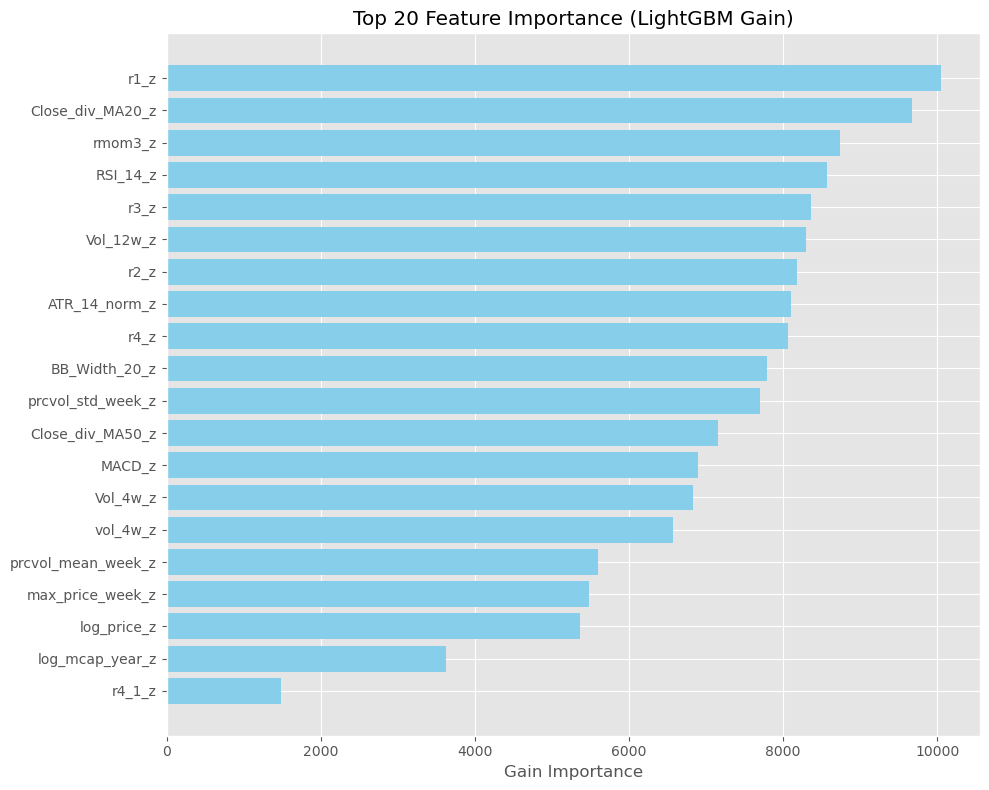

In [2]:
if IMP_FP.exists():
    imp = pd.read_csv(IMP_FP)
    print("Feature Importance Loaded. Shape:", imp.shape)
    
    # Sort and Plot Top 20
    imp = imp.sort_values("importance", ascending=True).tail(20)
    
    plt.figure(figsize=(10, 8))
    plt.barh(imp["feature"], imp["importance"], color="skyblue")
    plt.title("Top 20 Feature Importance (LightGBM Gain)")
    plt.xlabel("Gain Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance file not found at {IMP_FP}")

## 2. Backtest Summary

In [3]:
if SUM_FP.exists():
    with open(SUM_FP, "r") as f:
        summary = json.load(f)
    
    sum_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
    # Format numerics
    def format_val(x):
        if isinstance(x, float):
            return f"{x:.4f}"
        return x
    
    sum_df["Value"] = sum_df["Value"].apply(format_val)
    display(sum_df)
else:
    print(f"Backtest summary not found at {SUM_FP}")

,Metric,Value
0,weeks,321.0000
1,ann_return,0.7498
2,ann_vol,0.3697
3,sharpe,2.0282
4,mdd,-0.4611
5,avg_turnover,0.7172
6,avg_tc_bps,7.1718
7,beta_cmkt,0.0000


## 3. Equity Curve (Strategy vs BTC)

In [4]:
# Load Backtest Data
if BT_FP.exists():
    bt = pd.read_parquet(BT_FP)
    bt["date_week"] = pd.to_datetime(bt["date_week"])
    bt = bt.sort_values("date_week")
    print(f"Backtest data loaded: {len(bt)} weeks from {bt['date_week'].min().date()} to {bt['date_week'].max().date()}")
else:
    print("Backtest data not found.")
    bt = pd.DataFrame()

# Load Market Data (for BTC)
if FMP_FP.exists():
    fmp = pd.read_parquet(FMP_FP)
    fmp["date_week"] = pd.to_datetime(fmp["date_week"])
    
    # Check if BTC exists, else use CMKT
    bench_col = "BTC"
    if "BTC" not in fmp.columns:
        if "CMKT" in fmp.columns:
            bench_col = "CMKT"
        else:
            bench_col = None
            
    if bench_col:
        bench = fmp[["date_week", bench_col]].dropna()
        bench = bench.rename(columns={bench_col: "ret_bench"})
    else:
        print("No Benchmark (BTC/CMKT) found in FMP file.")
        bench = pd.DataFrame()
else:
    print("FMP file not found.")
    bench = pd.DataFrame()

Backtest data loaded: 321 weeks from 2019-08-04 to 2025-09-21


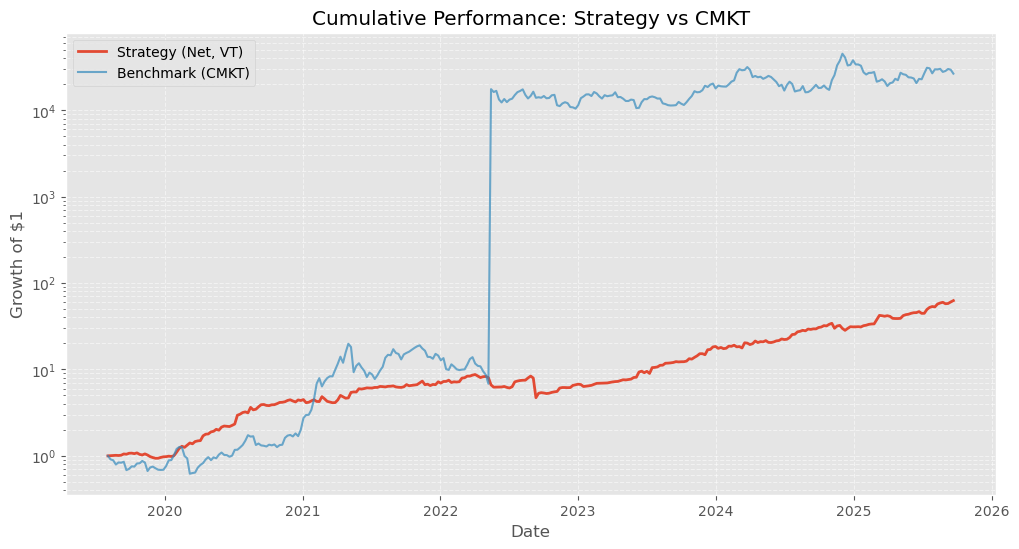

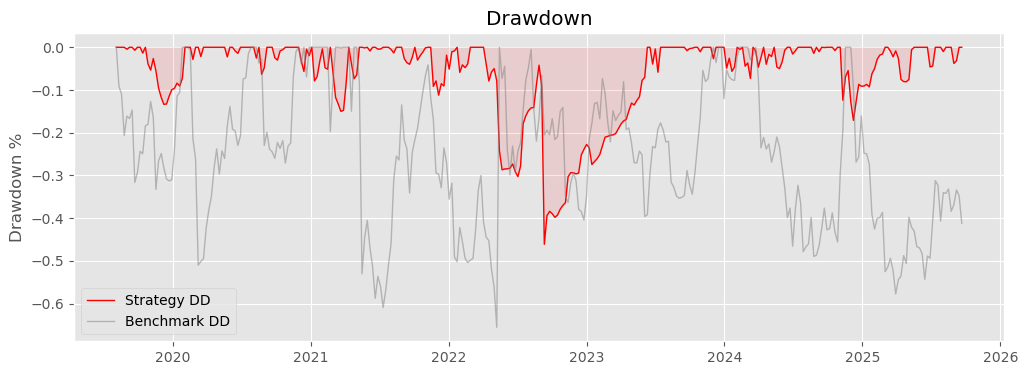

In [5]:
# Merge and Calculate Equity
if not bt.empty and not bench.empty:
    df = pd.merge(bt, bench, on="date_week", how="inner")
    
    # Calculate Cumulative Returns
    # Strategy (Vol Targeted Net Return)
    df["cum_strategy"] = (1 + df["ret_net_vt"]).cumprod()
    
    # Benchmark
    df["cum_bench"] = (1 + df["ret_bench"]).cumprod()
    
    # Normalize to start at 1
    df["cum_strategy"] = df["cum_strategy"] / df["cum_strategy"].iloc[0]
    df["cum_bench"] = df["cum_bench"] / df["cum_bench"].iloc[0]
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df["date_week"], df["cum_strategy"], label="Strategy (Net, VT)", linewidth=2)
    plt.plot(df["date_week"], df["cum_bench"], label=f"Benchmark ({bench_col})", linewidth=1.5, alpha=0.7)
    
    plt.title(f"Cumulative Performance: Strategy vs {bench_col}")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.show()
    
    # Drawdown Plot
    df["dd_strategy"] = (df["cum_strategy"] / df["cum_strategy"].cummax()) - 1
    df["dd_bench"] = (df["cum_bench"] / df["cum_bench"].cummax()) - 1
    
    plt.figure(figsize=(12, 4))
    plt.plot(df["date_week"], df["dd_strategy"], label="Strategy DD", color="red", linewidth=1)
    plt.plot(df["date_week"], df["dd_bench"], label="Benchmark DD", color="gray", alpha=0.5, linewidth=1)
    plt.title("Drawdown")
    plt.ylabel("Drawdown %")
    plt.legend()
    plt.fill_between(df["date_week"], df["dd_strategy"], 0, color="red", alpha=0.1)
    plt.show()
    
else:
    print("Could not merge data for plotting. Check date overlaps.")